In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Data

In [2]:
df = pd.read_csv("student_lifestyle_dataset.csv")

df.head()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       2000 non-null   int64  
 1   Study_Hours_Per_Day              2000 non-null   float64
 2   Extracurricular_Hours_Per_Day    2000 non-null   float64
 3   Sleep_Hours_Per_Day              2000 non-null   float64
 4   Social_Hours_Per_Day             2000 non-null   float64
 5   Physical_Activity_Hours_Per_Day  2000 non-null   float64
 6   GPA                              2000 non-null   float64
 7   Stress_Level                     2000 non-null   object 
dtypes: float64(6), int64(1), object(1)
memory usage: 125.1+ KB


Student_ID                         0
Study_Hours_Per_Day                0
Extracurricular_Hours_Per_Day      0
Sleep_Hours_Per_Day                0
Social_Hours_Per_Day               0
Physical_Activity_Hours_Per_Day    0
GPA                                0
Stress_Level                       0
dtype: int64

# Dropping unnecessary column

In [5]:
df.drop(columns=['Student_ID'], inplace=True)

# Checking unique stress levels

In [6]:
df['Stress_Level'].unique()

array(['Moderate', 'Low', 'High'], dtype=object)

# Encoding target variable

In [7]:
mapping = {
    'Low': 0,
    'Moderate': 1,
    'High': 2
}

df['Stress_Level'] = df['Stress_Level'].map(mapping)

# EDA

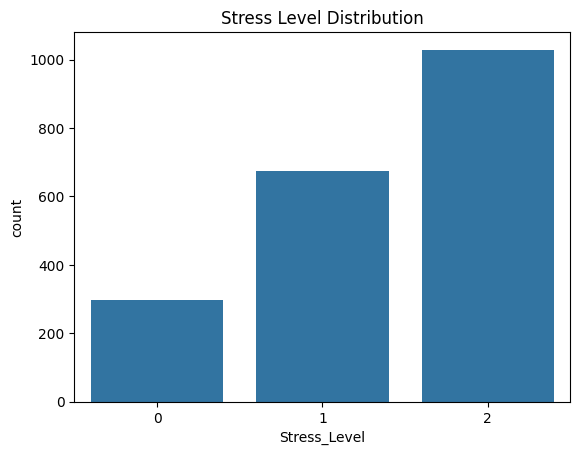

In [12]:
# Class distribution
sns.countplot(x='Stress_Level', data=df)
plt.title("Stress Level Distribution")
plt.show()

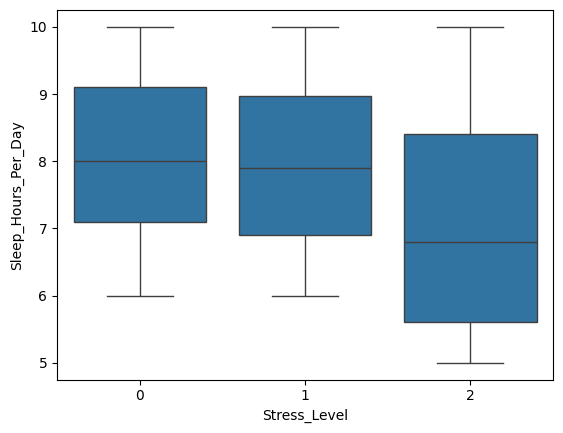

In [13]:
# Sleep vs Stress
sns.boxplot(x='Stress_Level', y='Sleep_Hours_Per_Day', data=df)
plt.show()

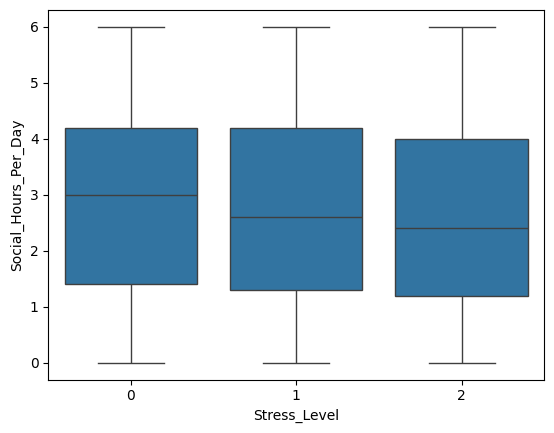

In [21]:
# Social time vs Stress
sns.boxplot(x='Stress_Level', y='Social_Hours_Per_Day', data=df)
plt.show()

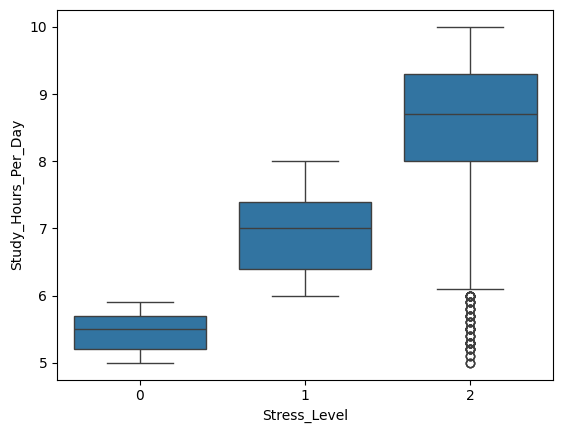

In [22]:
# Study time vs Stress
sns.boxplot(x='Stress_Level', y='Study_Hours_Per_Day', data=df)
plt.show()

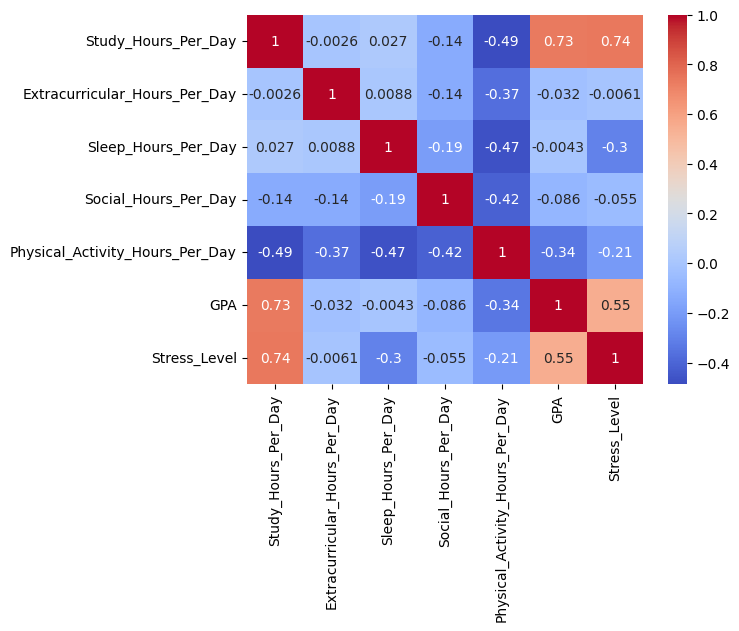

In [15]:
# Correlation
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# Model Building

In [23]:
# Features & Target
X = df[['Study_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'GPA']]
y = df['Stress_Level']

In [28]:
# Train-test split
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Train Model
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)



Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        67
           1       1.00      1.00      1.00       127
           2       1.00      1.00      1.00       206

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



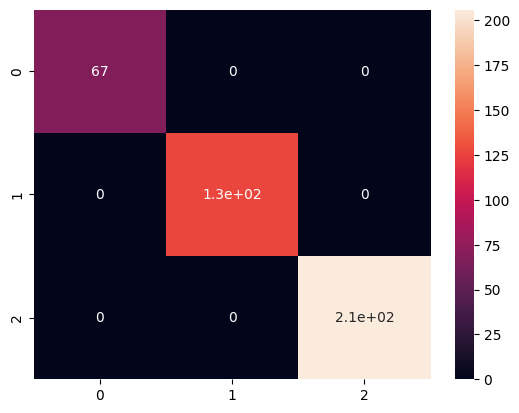

In [25]:
# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)
plt.show()

In [29]:
import pickle

# Save model
pickle.dump(model, open("model.pkl", "wb"))

print("Model trained and saved!")

Model trained and saved!
